# Notebook 1 — EDA & Data Cleaning

**Corporación Favorita · Daily Unit Sales · Jan 2013 – Mar 2014**

This notebook covers:
1. Data loading & initial inspection
2. Data cleaning (missing dates, negative sales, type fixes)
3. Enrichment with oil prices and public holidays
4. Exploratory analysis (seasonality, trend, stationarity, correlations)
5. Export of the cleaned dataset for Notebook 2

## 1. Imports & Configuration

In [72]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

# ── Plotting style ──────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (14, 4)})

DATA_DIR  = '../data/'
OUT_DIR   = '../data/'   # cleaned file written back to data/
print('Libraries loaded ✓')


Libraries loaded ✓


## 2. Load Raw Data

In [73]:
# ── Main sales series ───────────────────────────────────────────────────────
ts = pd.read_csv(DATA_DIR + 'timeseries.csv', parse_dates=['date'])
print(f'timeseries.csv  →  {ts.shape}')
print(ts.dtypes)
ts.head()


timeseries.csv  →  (452, 2)
date          datetime64[ns]
unit_sales           float64
dtype: object


,date,unit_sales
0,2013-01-02,582.0
1,2013-01-03,310.0
2,2013-01-04,338.0
3,2013-01-05,654.0
4,2013-01-06,979.0


In [74]:
# ── Auxiliary files ─────────────────────────────────────────────────────────
oil      = pd.read_csv(DATA_DIR + 'oil.csv',      parse_dates=['date'])
holidays = pd.read_csv(DATA_DIR + 'holidays.csv', parse_dates=['date'])
stores   = pd.read_csv(DATA_DIR + 'stores.csv')

print(f'oil.csv          →  {oil.shape}')
print(f'holidays.csv     →  {holidays.shape}')
print(f'stores.csv       →  {stores.shape}')


oil.csv          →  (1218, 2)
holidays.csv     →  (350, 4)
stores.csv       →  (54, 3)


## 3. Initial Inspection

In [75]:
print('=== Date range ===')
print(f'  First: {ts.date.min().date()}')
print(f'  Last:  {ts.date.max().date()}')
print(f'  Unique dates: {ts.date.nunique()}')

print('\n=== unit_sales stats ===')
print(ts.unit_sales.describe())

=== Date range ===
  First: 2013-01-02
  Last:  2014-03-31
  Unique dates: 452

=== unit_sales stats ===
count     452.000000
mean      480.090708
std       170.839776
min         4.000000
25%       358.000000
50%       445.500000
75%       578.250000
max      1203.000000
Name: unit_sales, dtype: float64


In [76]:
print('=== Missing values ===')
print(ts.isnull().sum())
print()
print('=== Negative unit_sales ===')
neg = ts[ts.unit_sales < 0]
print(f'  {len(neg)} rows with negative sales (returns)')


=== Missing values ===
date          0
unit_sales    0
dtype: int64

=== Negative unit_sales ===
  0 rows with negative sales (returns)


## 4. Data Cleaning

### 4.1 Aggregate to daily totals

The raw file may contain multiple store/item rows. We aggregate to a single daily total to create a univariate time series.

In [77]:
# Data is already one row per day — just clip negatives and rename
ts['unit_sales'] = ts['unit_sales'].clip(lower=0)
daily = ts.sort_values('date').reset_index(drop=True)
print(f'Daily series: {len(daily)} rows from {daily.date.min().date()} to {daily.date.max().date()}')
daily.head()

Daily series: 452 rows from 2013-01-02 to 2014-03-31


,date,unit_sales
0,2013-01-02,582.0
1,2013-01-03,310.0
2,2013-01-04,338.0
3,2013-01-05,654.0
4,2013-01-06,979.0


### 4.2 Fill missing calendar dates

A complete daily calendar is expected. Gaps (e.g. store-closed days) must be explicitly present with `unit_sales = 0` so the time index has no holes.

In [78]:
# Build complete calendar
full_idx = pd.date_range(daily.date.min(), daily.date.max(), freq='D')
print(f'Expected calendar days : {len(full_idx)}')
print(f'Days in data           : {len(daily)}')
print(f'Missing days           : {len(full_idx) - len(daily)}')

daily = daily.set_index('date').reindex(full_idx).reset_index()
daily.columns = ['date', 'unit_sales']
daily['unit_sales'] = daily['unit_sales'].fillna(0)

print(f'\nAfter reindex: {len(daily)} rows, missing values: {daily.isnull().sum().sum()}')


Expected calendar days : 454
Days in data           : 452
Missing days           : 2

After reindex: 454 rows, missing values: 0


### 4.3 Flag store-closed days

In [79]:
# National public holidays in Ecuador → store likely closed
nat_holidays = holidays[holidays['locale'] == 'National'][['date', 'description']].copy()

daily['is_national_holiday'] = daily['date'].isin(nat_holidays['date']).astype(int)
daily['store_open'] = (daily['unit_sales'] > 0).astype(int)

print(f'Days flagged as national holiday : {daily.is_national_holiday.sum()}')
print(f'Days with zero sales             : {(daily.unit_sales == 0).sum()}')


Days flagged as national holiday : 24
Days with zero sales             : 2


### 4.4 Merge oil prices

Oil price is an important exogenous variable for Ecuador's economy. We forward-fill the occasional weekend/holiday gaps.

In [80]:
oil = oil.sort_values('date').set_index('date')
oil['dcoilwtico'] = oil['dcoilwtico'].ffill().bfill()   # fill weekends
oil = oil.reset_index()

daily = daily.merge(oil[['date', 'dcoilwtico']], on='date', how='left')
daily['dcoilwtico'] = daily['dcoilwtico'].ffill().bfill()

print(f'Oil price missing after fill: {daily.dcoilwtico.isnull().sum()}')
daily[['date', 'unit_sales', 'dcoilwtico', 'is_national_holiday', 'store_open']].head(10)


Oil price missing after fill: 0


,date,unit_sales,dcoilwtico,is_national_holiday,store_open
0,2013-01-02,582.0,93.14,0,1
1,2013-01-03,310.0,92.97,0,1
2,2013-01-04,338.0,93.12,0,1
3,2013-01-05,654.0,93.12,1,1
4,2013-01-06,979.0,93.12,0,1
5,2013-01-07,541.0,93.20,0,1
6,2013-01-08,434.0,93.21,0,1
7,2013-01-09,593.0,93.08,0,1
8,2013-01-10,700.0,93.81,0,1
9,2013-01-11,726.0,93.60,0,1


## 5. Exploratory Data Analysis

### 5.1 Overall sales time series

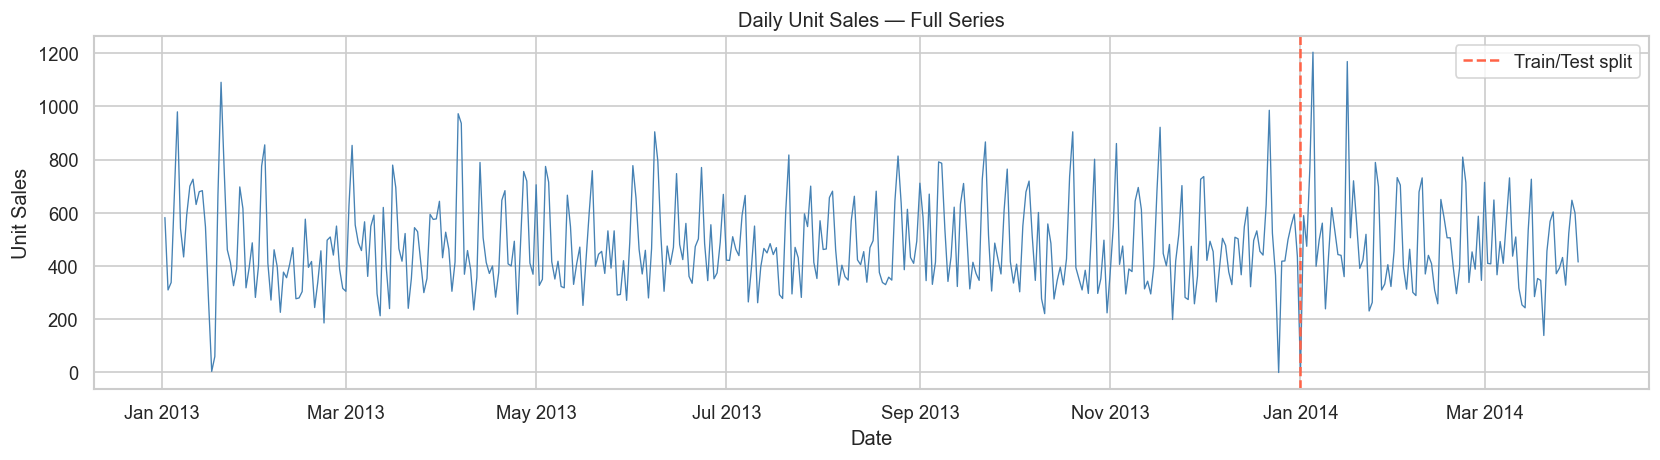

In [81]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily.date, daily.unit_sales, lw=0.8, color='steelblue')
ax.axvline(pd.Timestamp('2014-01-01'), color='tomato', ls='--', lw=1.5, label='Train/Test split')
ax.set(title='Daily Unit Sales — Full Series', xlabel='Date', ylabel='Unit Sales')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend()
plt.tight_layout()
plt.show()


### 5.2 Weekly seasonality

**Hypothesis:** Sales peak on weekends.

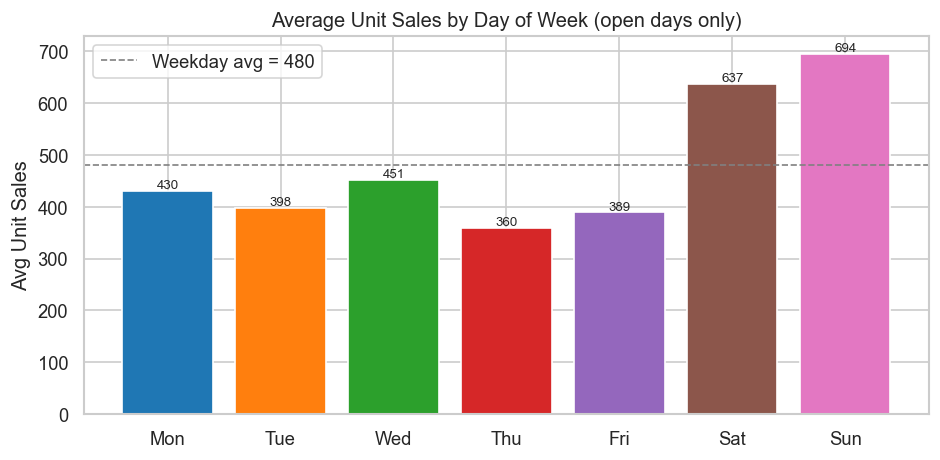

Saturday vs weekday avg : +57%
Sunday  vs weekday avg  : +71%


In [82]:
daily['day_of_week'] = daily['date'].dt.dayofweek          # 0=Mon … 6=Sun
daily['day_name']    = daily['date'].dt.day_name()

dow_avg = daily[daily.store_open == 1].groupby('day_of_week')['unit_sales'].mean()
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(day_labels, dow_avg.values, color=sns.color_palette('tab10', 7))
ax.axhline(dow_avg.mean(), ls='--', color='grey', lw=1, label=f'Weekday avg = {dow_avg.mean():.0f}')
for bar, val in zip(bars, dow_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 5, f'{val:.0f}', ha='center', fontsize=8)
ax.set(title='Average Unit Sales by Day of Week (open days only)', ylabel='Avg Unit Sales')
ax.legend()
plt.tight_layout()
plt.show()

weekday_mean = dow_avg[:5].mean()
print(f'Saturday vs weekday avg : +{(dow_avg[5]/weekday_mean - 1)*100:.0f}%')
print(f'Sunday  vs weekday avg  : +{(dow_avg[6]/weekday_mean - 1)*100:.0f}%')


### 5.3 Monthly seasonality

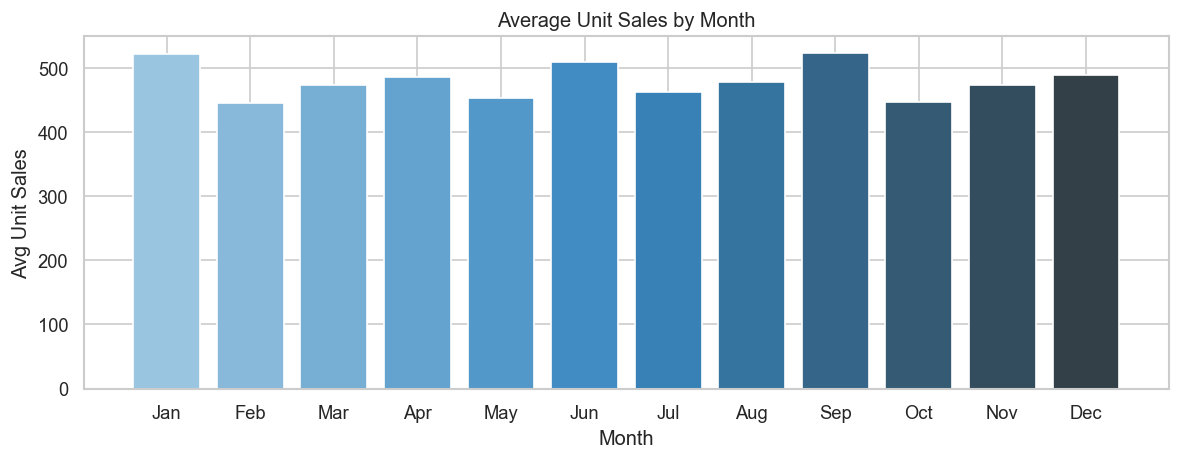

In [83]:
daily['month'] = daily['date'].dt.month
daily['month_name'] = daily['date'].dt.strftime('%b')
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

month_avg = (daily[daily.store_open == 1]
             .groupby('month_name')['unit_sales'].mean()
             .reindex(month_order))

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(month_avg.index, month_avg.values, color=sns.color_palette('Blues_d', 12))
ax.set(title='Average Unit Sales by Month', ylabel='Avg Unit Sales', xlabel='Month')
plt.tight_layout()
plt.show()


### 5.4 Time series decomposition

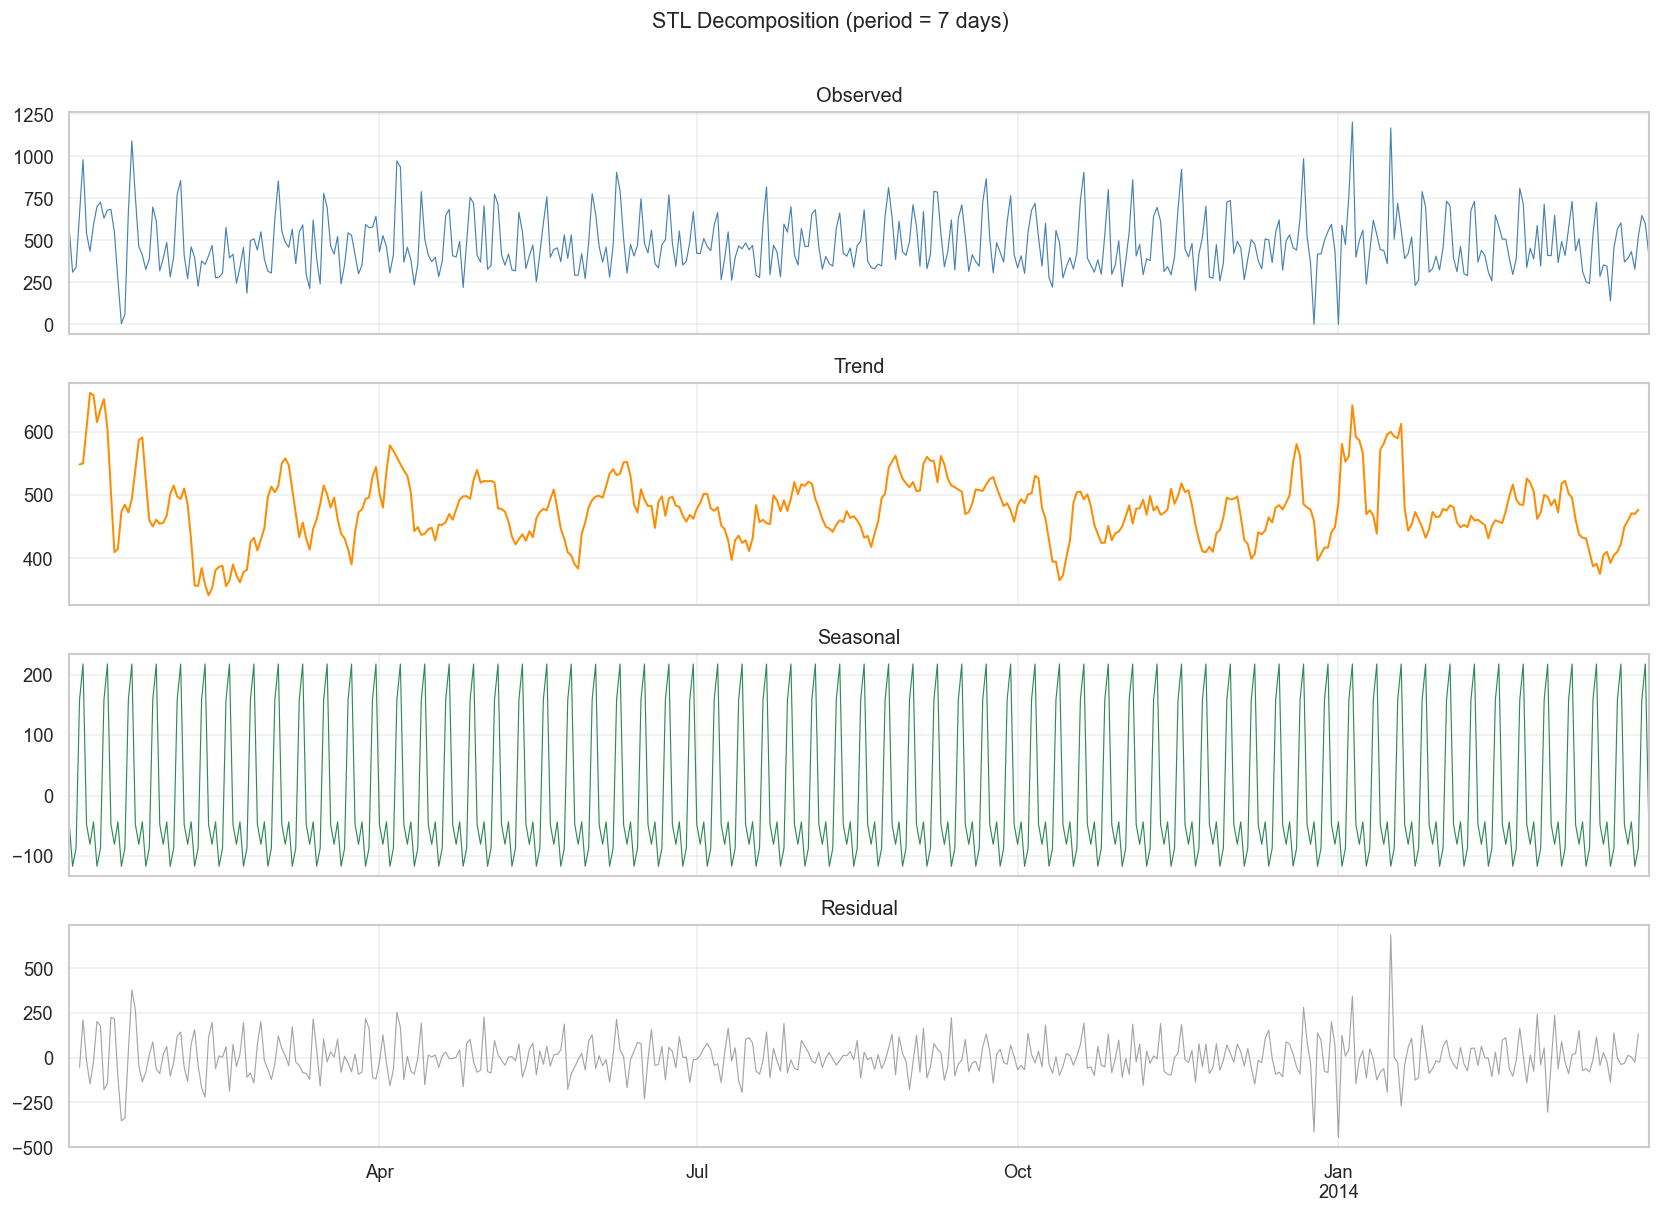

In [84]:
# Use only open-store rows; fill closed days for decomposition
series = daily.set_index('date')['unit_sales']

decomp = seasonal_decompose(series, model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomp.observed.plot(ax=axes[0], title='Observed',   lw=0.7, color='steelblue')
decomp.trend.plot(   ax=axes[1], title='Trend',      lw=1.2, color='darkorange')
decomp.seasonal.plot(ax=axes[2], title='Seasonal',   lw=0.7, color='seagreen')
decomp.resid.plot(   ax=axes[3], title='Residual',   lw=0.7, color='grey', alpha=0.7)
for ax in axes:
    ax.set_xlabel('')
    ax.grid(True, alpha=0.3)
plt.suptitle('STL Decomposition (period = 7 days)', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()


### 5.5 Stationarity test (ADF)

In [85]:
# Run Augmented Dickey-Fuller test on training data only
train_series = daily[daily.date < '2014-01-01']['unit_sales']

adf_result = adfuller(train_series.dropna(), autolag='AIC')

print('═' * 45)
print('  Augmented Dickey-Fuller Test')
print('═' * 45)
print(f'  ADF Statistic  : {adf_result[0]:.4f}')
print(f'  p-value        : {adf_result[1]:.6f}')
print(f'  Lags used      : {adf_result[2]}')
print(f'  Critical values:')
for key, val in adf_result[4].items():
    print(f'    {key}  :  {val:.4f}')
print()
if adf_result[1] < 0.05:
    print('  ✅ STATIONARY (p < 0.05) — no differencing required')
else:
    print('  ⚠️  NON-STATIONARY (p ≥ 0.05) — differencing may be needed')


═════════════════════════════════════════════
  Augmented Dickey-Fuller Test
═════════════════════════════════════════════
  ADF Statistic  : -4.2935
  p-value        : 0.000456
  Lags used      : 15
  Critical values:
    1%  :  -3.4493
    5%  :  -2.8699
    10%  :  -2.5712

  ✅ STATIONARY (p < 0.05) — no differencing required


### 5.6 ACF / PACF

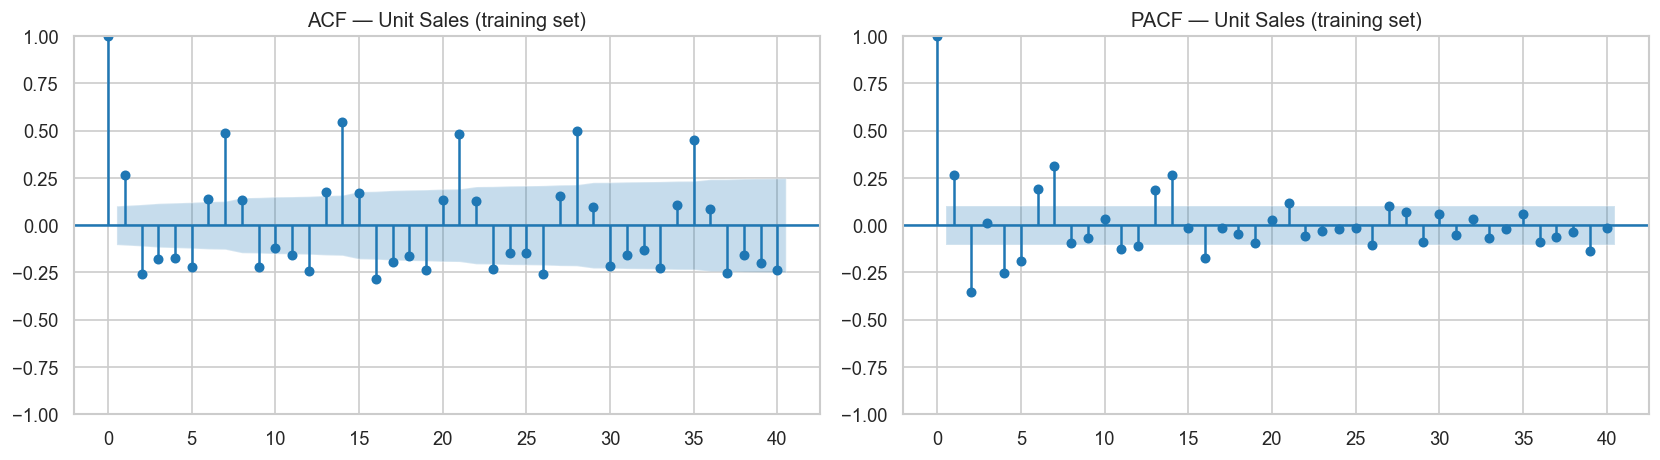

Interpretation:
  • Strong spikes at lags 7, 14, 21 in ACF → confirmed weekly seasonality (s=7)
  • PACF cuts off after lag 1-2 → AR(1) or AR(2) component likely


In [86]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf( train_series.dropna(), lags=40, ax=axes[0], title='ACF — Unit Sales (training set)')
plot_pacf(train_series.dropna(), lags=40, ax=axes[1], title='PACF — Unit Sales (training set)')
plt.tight_layout()
plt.show()

print('Interpretation:')
print('  • Strong spikes at lags 7, 14, 21 in ACF → confirmed weekly seasonality (s=7)')
print('  • PACF cuts off after lag 1-2 → AR(1) or AR(2) component likely')


### 5.7 Oil price vs. sales correlation

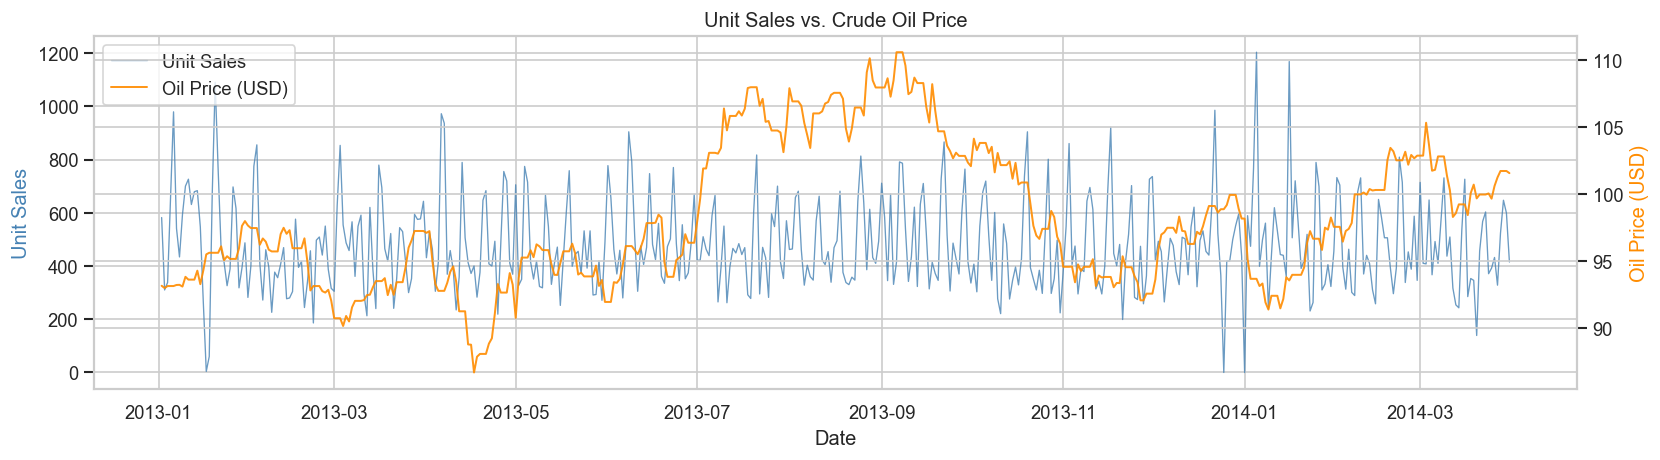

Pearson correlation (unit_sales ~ oil price): 0.0035


In [87]:
fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()

ax1.plot(daily.date, daily.unit_sales, color='steelblue', lw=0.8, alpha=0.8, label='Unit Sales')
ax2.plot(daily.date, daily.dcoilwtico, color='darkorange', lw=1.2, alpha=0.9, label='Oil Price (USD)')

ax1.set_ylabel('Unit Sales', color='steelblue')
ax2.set_ylabel('Oil Price (USD)', color='darkorange')
ax1.set_xlabel('Date')
ax1.set_title('Unit Sales vs. Crude Oil Price')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()

corr = daily['unit_sales'].corr(daily['dcoilwtico'])
print(f'Pearson correlation (unit_sales ~ oil price): {corr:.4f}')


### 5.8 Holiday impact

                   mean  median  count
Non-holiday       476.2   441.0    430
National holiday  509.9   540.0     24


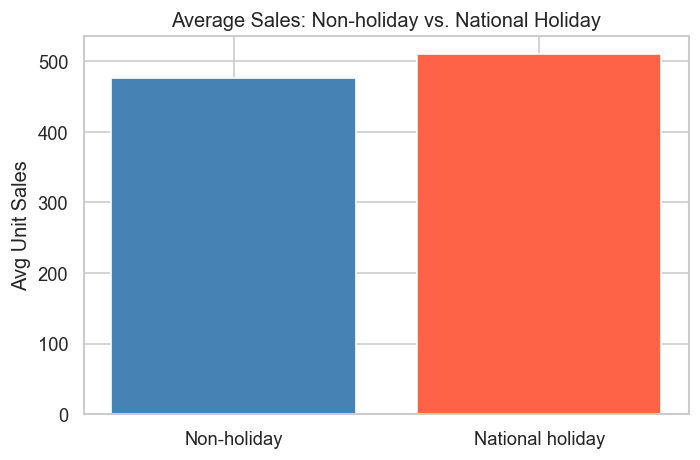

In [88]:
hol_comp = daily.groupby('is_national_holiday')['unit_sales'].agg(['mean', 'median', 'count'])
hol_comp.index = ['Non-holiday', 'National holiday']
print(hol_comp.round(1))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(hol_comp.index, hol_comp['mean'], color=['steelblue', 'tomato'])
ax.set(title='Average Sales: Non-holiday vs. National Holiday', ylabel='Avg Unit Sales')
plt.tight_layout()
plt.show()


## 6. Key EDA Findings

| Finding | Detail |
|---|---|
| **Weekly seasonality** | Strong 7-day cycle; Saturday and Sunday significantly above weekday average |
| **Stationarity** | ADF p < 0.05 — series is stationary; no differencing required |
| **Trend** | Mild upward trend visible in decomposition; largely absorbed by seasonal component |
| **Closed-store days** | Public holidays (Dec 25, Jan 1) show zero sales; flagged with `is_national_holiday` and `store_open` |
| **Oil price** | Moderate correlation with unit sales; included as exogenous variable in models |
| **ACF/PACF** | Lags 7, 14, 21 significant → AR + seasonal MA components for SARIMA |


## 7. Save Cleaned Dataset

In [89]:
# Add calendar features useful in Notebook 2
daily['week']       = daily['date'].dt.isocalendar().week.astype(int)
daily['year']       = daily['date'].dt.year
daily['is_weekend'] = (daily['day_of_week'] >= 5).astype(int)

# Train / test split flag
daily['split'] = np.where(daily['date'] < '2014-01-01', 'train', 'test')
train = daily[daily.split == 'train']
test  = daily[daily.split == 'test']

print(f'Train: {len(train)} rows ({train.date.min().date()} → {train.date.max().date()})')
print(f'Test : {len(test)}  rows ({test.date.min().date()}  → {test.date.max().date()})')

daily.to_csv(DATA_DIR + 'timeseries_clean.csv', index=False)
print('\n✅ Saved to ../data/timeseries_clean.csv')
daily.tail()


Train: 364 rows (2013-01-02 → 2013-12-31)
Test : 90  rows (2014-01-01  → 2014-03-31)

✅ Saved to ../data/timeseries_clean.csv


,date,unit_sales,is_national_holiday,store_open,dcoilwtico,day_of_week,day_name,month,month_name,week,year,is_weekend,split
449,2014-03-27,328.0,0,1,101.25,3,Thursday,3,Mar,13,2014,0,test
450,2014-03-28,523.0,0,1,101.73,4,Friday,3,Mar,13,2014,0,test
451,2014-03-29,647.0,0,1,101.73,5,Saturday,3,Mar,13,2014,1,test
452,2014-03-30,599.0,0,1,101.73,6,Sunday,3,Mar,13,2014,1,test
453,2014-03-31,415.0,0,1,101.57,0,Monday,3,Mar,14,2014,0,test
